In [1]:
import sys
sys.path.append('../')

import numpy as np
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score
from src.utils.data_loader import load_breast_cancer_data, load_folktables_income_data, load_loan_prediction, \
    load_folktables_employment_data, load_hr_analytics

random_state = 5
parameter_grid = {
        "min_impurity_decrease": [
            0.001,
            0.005,
            0.01,
            0.05,
            0.1,
        ]
    }

In [ ]:
for data_set_loader in (load_hr_analytics, load_breast_cancer_data, load_folktables_income_data, load_loan_prediction, 
    load_folktables_employment_data):
    df, columns, target = data_set_loader()
    if len(df) > 20000:
        df = df.sample(20000)
    X_train, X_test, y_train, y_test = train_test_split(df[columns], df[target], test_size=0.2, random_state=random_state)
    estimator = RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=random_state)
    
    grid_search = GridSearchCV(estimator=estimator, param_grid=parameter_grid, n_jobs=1, cv=10)
    grid_search.fit(X_train[columns], y_train)
    explainer = shap.TreeExplainer(grid_search.best_estimator_)
    shap_values = explainer.shap_values(X_test[columns])[1]
    mean_shap_values = np.mean(np.abs(shap_values), axis=0)
    indices = np.argsort(mean_shap_values, axis=0)[:-6:-1]

    print(data_set_loader.__name__)
    print(grid_search.best_score_)
    print(grid_search.score(X_test[columns], y_test))
    print(f"AUROC: {roc_auc_score(y_test, grid_search.predict_proba(X_test[columns])[:, 1])}")
    print(columns[indices])
    print("\n")

### Bias columns
Breast Cancer = uniformity_of_cell_size \
Folktables Income = WKHP\
Folktables Employment  = AGEP \
Loan Prediction = Credit_History \
HR Analytic = city_development_index

In [2]:
df, columns, target = load_folktables_income_data()

In [3]:
unbiased_probabilities = (df.WKHP.sort_values().value_counts() / len(df))
mean_wkhp = np.mean(df.WKHP)
sample_percentage = unbiased_probabilities[df.WKHP.values].values
sample_percentage[df.WKHP < mean_wkhp] = sample_percentage[df.WKHP < mean_wkhp] - 0.025
sample_percentage[df.WKHP > mean_wkhp] = sample_percentage[df.WKHP > mean_wkhp] + 0.025
sample_percentage[sample_percentage < 0] = 0
N = df.sample(frac=0.7, replace=False, weights=sample_percentage)

In [12]:
from src.utils.sampling import sample

N, R = sample(
           "most_important_feature",
           df,
           target,
           train_fraction=0.5,
           bias_fraction=0.8,
           columns=columns,
       )

<Axes: xlabel='WKHP', ylabel='Percent'>

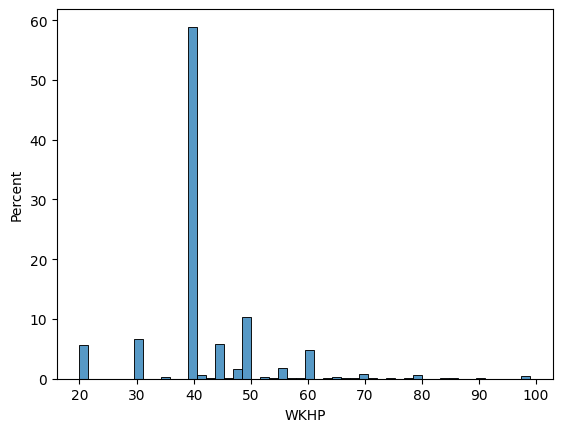

In [13]:
import seaborn as sns

sns.histplot(data=N, x="WKHP", bins=50, stat="percent")

<Axes: xlabel='WKHP', ylabel='Percent'>

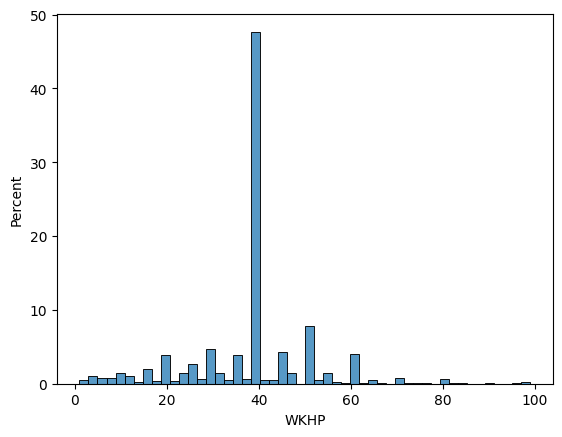

In [14]:
sns.histplot(data=R, x="WKHP", bins=50, stat="percent")